# Задание № 1

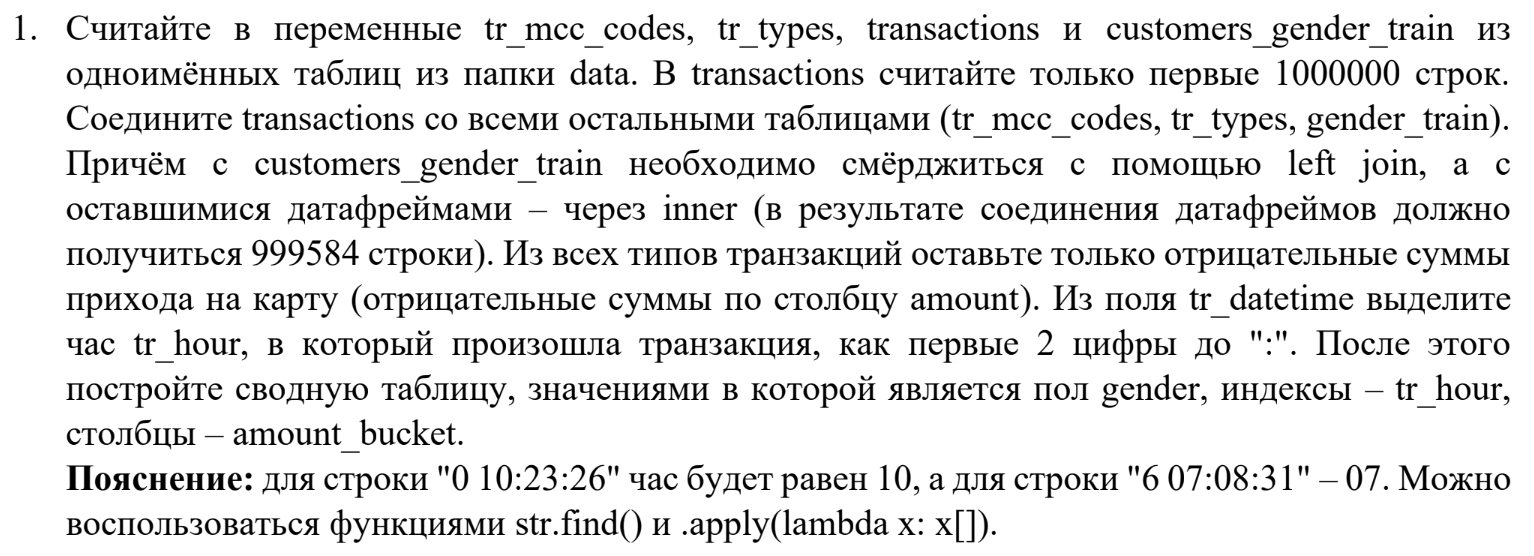

In [1]:
import numpy as np
import pandas as pd

In [2]:
tr_mcc_codes = pd.read_csv("/content/drive/MyDrive/data/tr_mcc_codes.csv", sep=";")
tr_types = pd.read_csv("/content/drive/MyDrive/data/tr_types.csv", sep=";")
transactions = pd.read_csv("/content/drive/MyDrive/data/transactions.csv", nrows=1_000_000)
customers_gender_train = pd.read_csv("/content/drive/MyDrive/data/gender_train.csv")

In [3]:
transactions = (
    transactions
        .merge(customers_gender_train, on="customer_id", how="left")
        .merge(tr_mcc_codes, on="mcc_code", how="inner")
        .merge(tr_types, on="tr_type", how="inner")
)

In [4]:
len(transactions)

999584

In [5]:
transactions.insert(
    loc = transactions.columns.get_loc("amount") + 1,
    column = "category",
    value = pd.Categorical(
        np.where(transactions["amount"] >= 0, "Income", "Outcome")
    )
)

In [6]:
transactions.insert(
    loc = transactions.columns.get_loc("tr_datetime") + 1,
    column = "tr_hour",
    value = (
        transactions["tr_datetime"]
            .dropna()
            .apply(lambda x: x.split()[1].split(":")[0])
    )
)

In [7]:
transactions.head(2)

,customer_id,tr_datetime,tr_hour,mcc_code,tr_type,amount,category,term_id,gender,mcc_description,tr_description
0,39026145,0 10:23:26,10,4814,1030,-2245.92,Outcome,NaN,1.0,"Звонки с использованием телефонов, считывающих...",Оплата услуги. Банкоматы СБ РФ
1,39026145,1 10:19:29,10,6011,7010,56147.89,Income,NaN,1.0,Финансовые институты — снятие наличности автом...,Взнос наличных через АТМ (в своем тер.банке)


---

In [8]:
income_transactions = (
    transactions.where(
        transactions["category"] == "Income"
    )
)

In [9]:
income_transactions_gender = (
    income_transactions.pivot_table(
        values="gender",
        index="tr_hour",
        observed=False
    )
)

In [10]:
income_transactions_count = (
    income_transactions.pivot_table(
        values="customer_id",
        index="tr_hour",
        aggfunc="count",
        observed=False
    )
)

---

In [11]:
outcome_transactions = (
    transactions.where(
        transactions["category"] == "Outcome"
    )
)

In [12]:
labels = ["very_low", "low", "middle", "high", "very_high"]

In [13]:
outcome_transactions["amount_bucket"] = (
    pd.qcut(
        outcome_transactions["amount"].abs(),
        q=len(labels),
        labels=labels
    ).astype("category")
)

In [14]:
outcome_transactions_gender = (
    outcome_transactions.pivot_table(
        values="gender",
        index="tr_hour",
        columns="amount_bucket",
        observed=False
    )
)

# Задание № 2

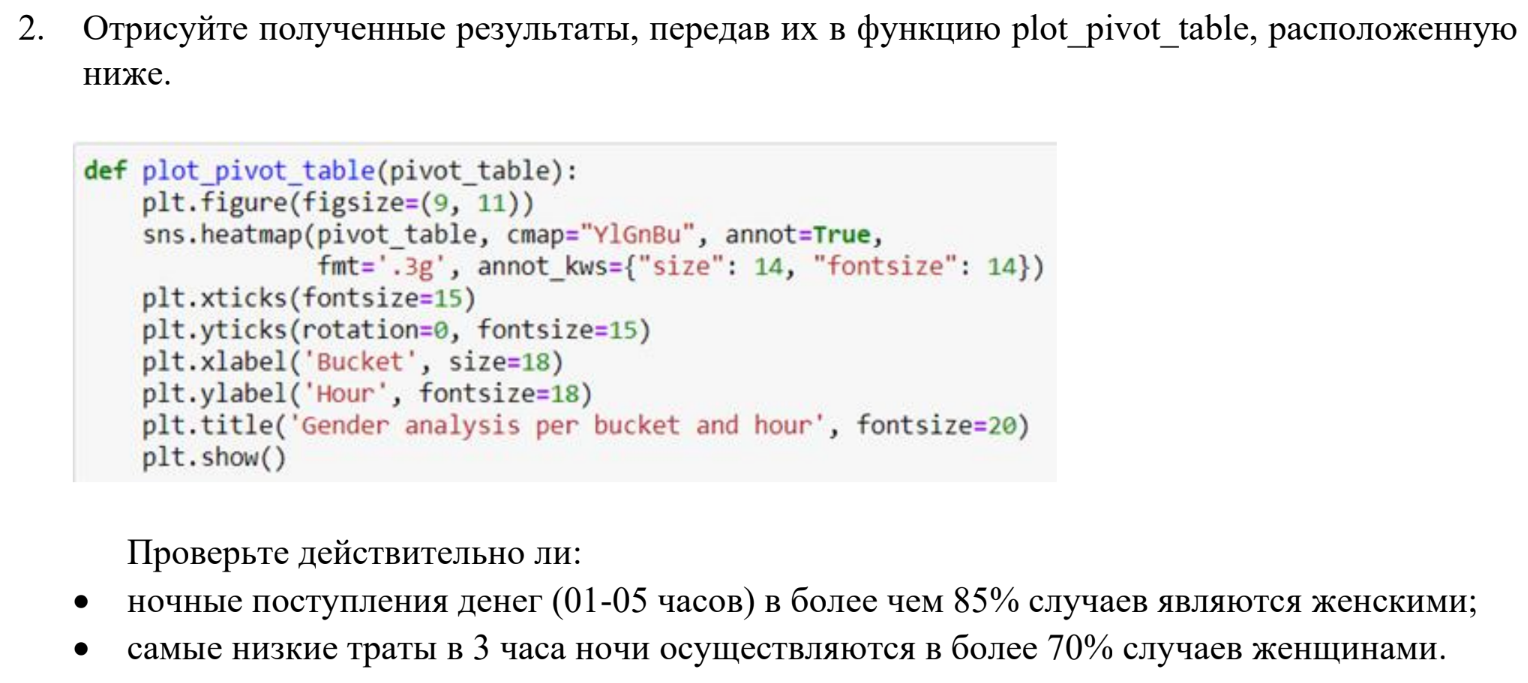

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
def plot_pivot_table(pivot_table, annot=True, fmt=""):
    plt.figure(figsize=(9, 11))
    sns.heatmap(pivot_table, cmap="YlGnBu", annot=annot, fmt=fmt, annot_kws={"size": 14})
    plt.xticks(fontsize=15)
    plt.yticks(rotation=0, fontsize=15)
    plt.xlabel("Bucket", size=18)
    plt.ylabel("Hour", fontsize=18)
    plt.title("Gender analysis per bucket and hour", fontsize=20)
    plt.show()

---

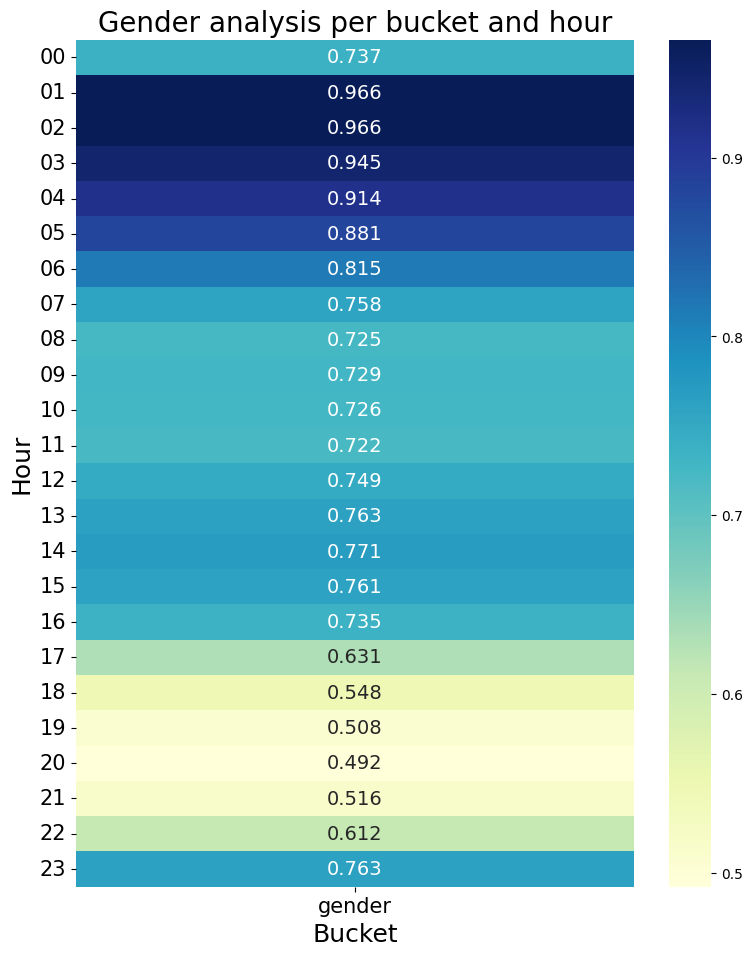

In [17]:
plot_pivot_table(income_transactions_gender, fmt=".3g")

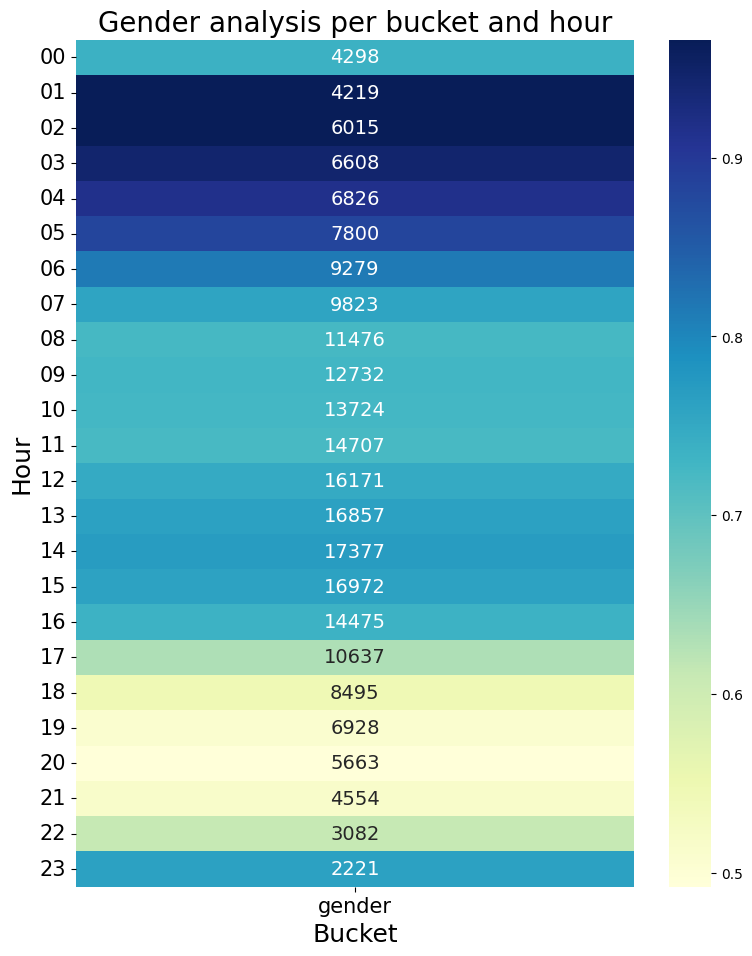

In [18]:
plot_pivot_table(income_transactions_gender, annot=income_transactions_count)

In [19]:
gender = income_transactions_gender.loc["01":"05", "gender"]
count = income_transactions_count.loc["01":"05", "customer_id"]

print(1 - (gender * count).sum() / count.sum())

0.0707351629296813


---

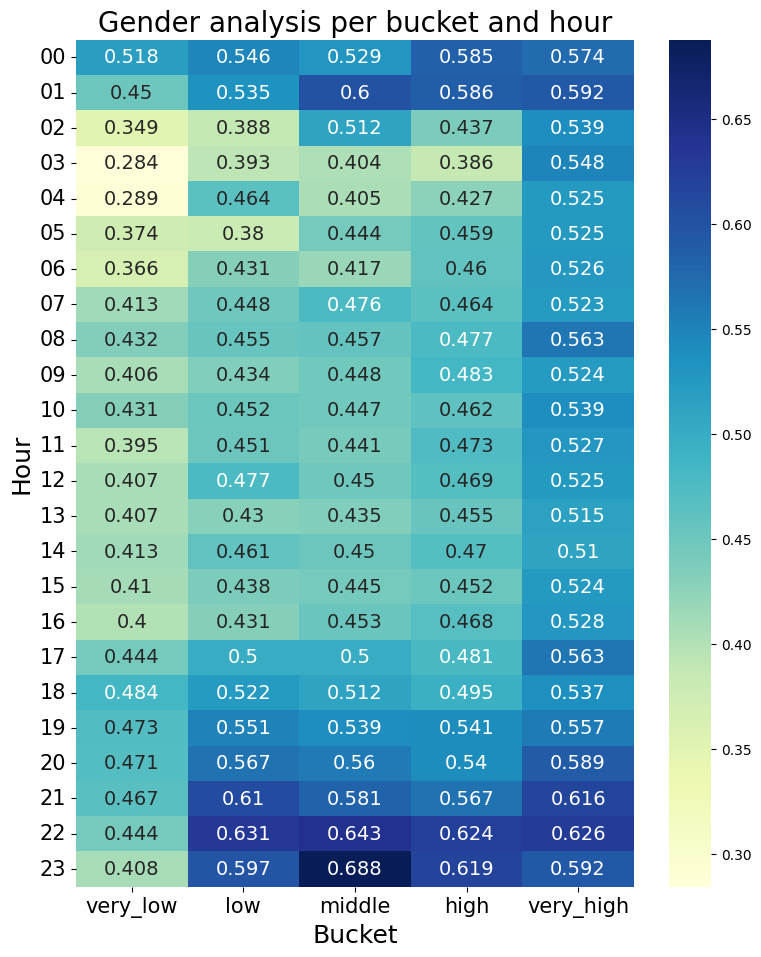

In [20]:
plot_pivot_table(outcome_transactions_gender, fmt=".3g")

In [21]:
print(1 - outcome_transactions_gender.at["03", "very_low"])

0.7156673114119922
